<a href="https://www.kaggle.com/code/unknownotaku/linear-regression?scriptVersionId=343799733" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

                    song_name  song_popularity  song_duration_ms  \
0  Boulevard of Broken Dreams               73            262333   
1                  In The End               66            216933   
2           Seven Nation Army               76            231733   
3                  By The Way               74            216933   
4           How You Remind Me               56            223826   

   acousticness  danceability  energy  instrumentalness  key  liveness  \
0      0.005520         0.496   0.682          0.000029    8    0.0589   
1      0.010300         0.542   0.853          0.000000    3    0.1080   
2      0.008170         0.737   0.463          0.447000    0    0.2550   
3      0.026400         0.451   0.970          0.003550    0    0.1020   
4      0.000954         0.447   0.766          0.000000   10    0.1130   

   loudness  audio_mode  speechiness    tempo  time_signature  audio_valence  
0    -4.095           1       0.0294  167.060               4      

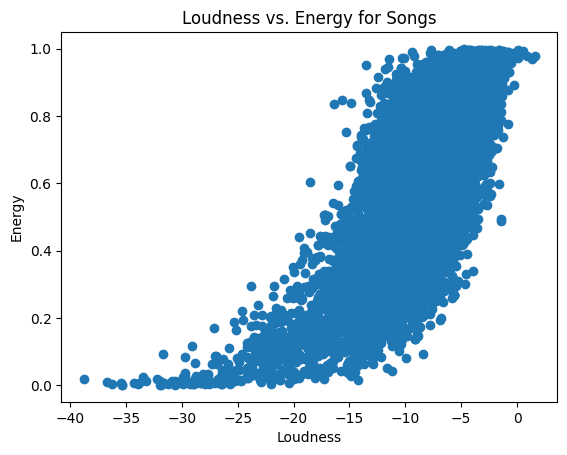

(15068, 15)
(3767, 15)


In [1]:
import numpy as np 
import pandas as pd 
from matplotlib import pyplot as plt
df = pd.read_csv("/kaggle/input/datasets/unknownotaku/song-data/song_data.csv")
df1 = df.copy()
df1.dropna()
print(df1.head(5))
x= df1.iloc[:,9]
y = df1.iloc[:,5]
plt.scatter(x,y)
plt.xlabel("Loudness")
plt.ylabel("Energy")
plt.title("Loudness vs. Energy for Songs")
plt.show()
df_train = df1.sample(frac=0.8)
df_test = df1.drop(df_train.index)
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
print(df_train.shape)
print(df_test.shape)

# **1. Linear Regression Using Gradient Descent:** 

![](https://mccormickml.com/assets/GradientDescent/GradientDescentOfMSETable.png)

/tmp/ipykernel_16/2875660595.py:24: RuntimeWarning: overflow encountered in scalar add
  d_dm += self.x[i] * (self.y[i] - (self.m*self.x[i] + self.b))
/tmp/ipykernel_16/2875660595.py:27: RuntimeWarning: invalid value encountered in scalar add
  d_db += (self.y[i] - (self.m*self.x[i] + self.b))


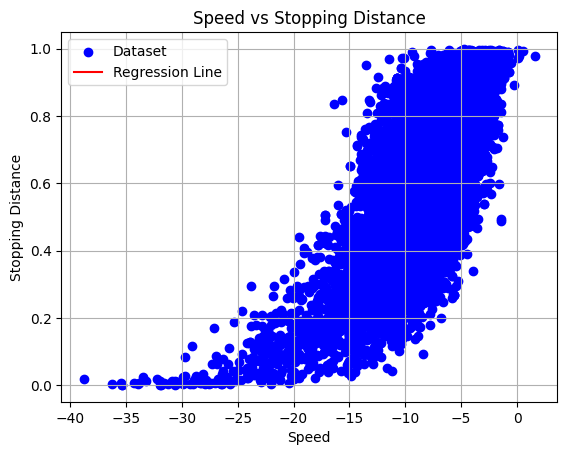

nan nan


In [2]:
class gradient_descent:
    def __init__(self,train_df, lr, iterations):
        self.df = train_df
        self.x = self.df.iloc[:, 9].to_numpy()
        self.y = self.df.iloc[:, 5].to_numpy()

        self.iterations = iterations
        self.m = 0
        self.b = 0
        self.lr = lr

    def MSE(self):
        sumsqr = 0
        mse = 0
        for i in range(len(self.x)):
            sumsqr += pow(self.y[i] - (self.m*self.x[i]+self.b),2)
        mse = sumsqr/(2*len(self.x))
        return mse

    def gradient(self):
        d_dm = 0
        d_db = 0
        for i in range(len(self.x)):
            d_dm += self.x[i] * (self.y[i] - (self.m*self.x[i] + self.b))
        d_dm *= 1/len(self.x)
        for i in range(len(self.x)):
            d_db += (self.y[i] - (self.m*self.x[i] + self.b))
        d_db *= 1/len(self.x)
        return d_dm, d_db

    def descent(self):
        for j in range(self.iterations): 
            d_dm, d_db = self.gradient()
            self.m -= self.lr * d_dm
            self.b -= self.lr * d_db
            #print(f"Round: {j}, MSE = {self.MSE()}")
        plt.scatter(self.x, self.y, color="blue", label="Dataset")
        y_hat = self.m * self.x + self.b
        plt.plot(self.x, y_hat, color="red", label="Regression Line")
        plt.xlabel("Speed")
        plt.ylabel("Stopping Distance")
        plt.title('Speed vs Stopping Distance')
        plt.legend()
        plt.grid(True)
        plt.show()

    def test(self, test_df):
        self.df = test_df
        self.x = self.df.iloc[:, 9].to_numpy()
        self.y = self.df.iloc[:, 5].to_numpy()
        
        plt.scatter(self.x, self.y, color="blue", label="Dataset")
        y_hat = self.m * self.x + self.b
        plt.plot(self.x, y_hat, color="red", label="Regression Line")
        plt.xlabel("Speed")
        plt.ylabel("Stopping Distance")
        plt.title('Speed vs Stopping Distance')
        plt.legend()
        plt.grid(True)
        plt.show()
        print(f"Result: MSE = {self.MSE()}")
        
model2 = gradient_descent(df_train, 0.001, 100000)
train = model2.descent()
print(model2.m, model2.b)


# **2. Linear Regression Using Gradient Descent (Matrices Form):** 

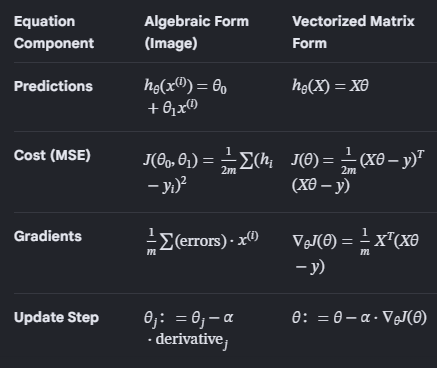

Round: 99999, MSE = [[0.00976941]]


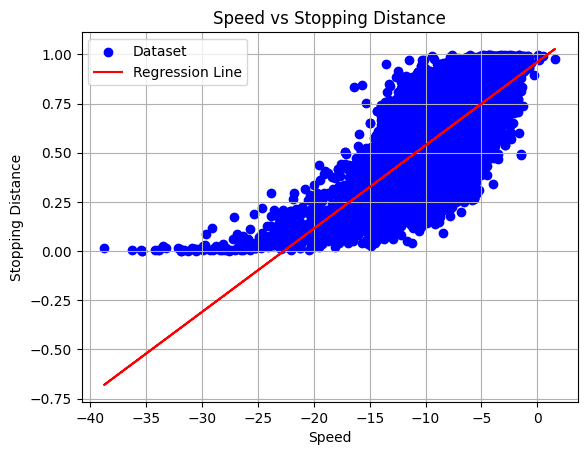

Result: MSE = [[0.0101052]]


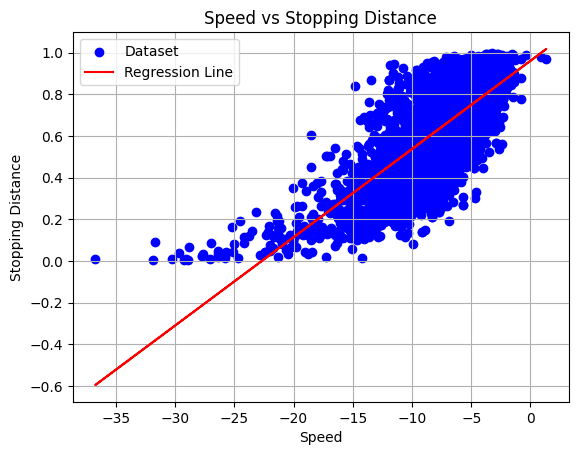

[[0.96061905]
 [0.04234116]]


In [3]:
class mat_gradient_descent:
    def __init__(self, train_df,lr, iterations):
        self.df = train_df
        self.samples, self.features = self.df.shape
        self.x = np.c_[np.ones((self.samples, 1)), np.array(self.df.iloc[:, 9]).reshape(-1, 1)]
        self.y = np.array(self.df.iloc[:, 5]).reshape(-1, 1)
        self.w = np.array([0]*2).reshape(-1,1)
        self.lr = lr
        self.iterations = iterations
        
    def MSE(self):
        h = np.dot(self.x, self.w)
        mse = np.dot((h - self.y).T, (h - self.y)) * (1/(2*self.samples))
        return mse

    def gradient(self):
        h = np.dot(self.x, self.w)
        grad = np.dot(self.x.T,  (h - self.y)) * (1/(self.samples))
        return grad

    def descent(self):
        for j in range(self.iterations):
            grad = self.gradient()
            self.w = self.w - np.dot(self.lr, grad)
        print(f"Round: {j}, MSE = {self.MSE()}")
        
        h = np.dot(self.x, self.w)
        plt.scatter(self.x[:,1], self.y, color="blue", label="Dataset")
        plt.plot(self.x[:,1], h, color="red", label="Regression Line")
        plt.xlabel("Speed")
        plt.ylabel("Stopping Distance")
        plt.title('Speed vs Stopping Distance')
        plt.legend()
        plt.grid(True)
        plt.show()

    def test(self, test_df):
        self.df = test_df
        self.samples, self.features = self.df.shape
        self.x = np.c_[np.ones((self.samples, 1)), np.array(self.df.iloc[:, 9]).reshape(-1, 1)]
        self.y = np.array(self.df.iloc[:, 5]).reshape(-1, 1)

        h = np.dot(self.x, self.w)
        plt.scatter(self.x[:,1], self.y, color="blue", label="Dataset")
        plt.plot(self.x[:,1], h, color="red", label="Regression Line")
        plt.xlabel("Speed")
        plt.ylabel("Stopping Distance")
        plt.title('Speed vs Stopping Distance')
        plt.legend()
        plt.grid(True)
        print(f"Result: MSE = {self.MSE()}")
        plt.show()
        

model1 = mat_gradient_descent(df_train, 0.01, 100000)
model1.descent()
model1.test(df_test)
print(model1.w)

# **3. The Normal Equation (Matrices):**

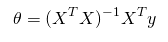

Training MSE = [[0.00976941]]


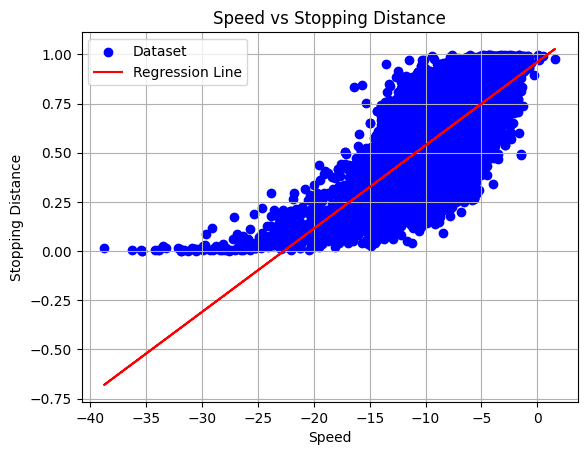

Testing MSE = [[0.0101052]]


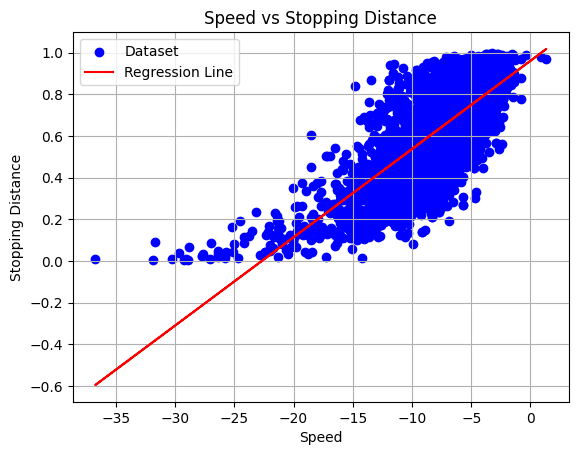

[[0.96061905]
 [0.04234116]]


In [4]:
class  the_normal_eq:
    def __init__(self, train_df):
        self.df = train_df
        self.m, self.n = self.df.shape
        self.w = np.array([0]*self.n).reshape(self.n,1)
        self.x = np.c_[np.ones((self.m, 1)), np.array(self.df.iloc[:, 9]).reshape(-1, 1)]
        self.y = np.array(self.df.iloc[:, 5]).reshape(-1, 1)


    def norm_eq(self):
        self.w = np.linalg.inv(self.x.T@self.x)@ self.x.T @ self.y
        h = self.x @ self.w
        mse = np.dot((h - self.y).T, (h - self.y)) * (1/(2*self.m))
        print(f"Training MSE = {mse}")
        plt.scatter(self.x[:,1], self.y, color="blue", label="Dataset")
        plt.plot(self.x[:,1], h, color="red", label="Regression Line")
        plt.legend()
        plt.grid(True)
        plt.xlabel("Speed")
        plt.ylabel("Stopping Distance")
        plt.title('Speed vs Stopping Distance')
        plt.show()

    def test(self, test_df):
        self.df = test_df
        self.m, self.n = self.df.shape
        self.x = np.c_[np.ones((self.m, 1)), np.array(self.df.iloc[:, 9]).reshape(-1, 1)]
        self.y = np.array(self.df.iloc[:, 5]).reshape(-1, 1)

        
        h = self.x @ self.w
        mse = np.dot((h - self.y).T, (h - self.y)) * (1/(2*self.m))
        print(f"Testing MSE = {mse}")
        plt.scatter(self.x[:,1], self.y, color="blue", label="Dataset")
        plt.plot(self.x[:,1], h, color="red", label="Regression Line")
        plt.legend()
        plt.grid(True)
        plt.xlabel("Speed")
        plt.ylabel("Stopping Distance")
        plt.title('Speed vs Stopping Distance')
        plt.show()
model3 = the_normal_eq(df_train)
model3.norm_eq()
model3.test(df_test)
print(model3.w)